###K-Nearest Neighbors (KNN)
K-Nearest Neighbors (KNN) is one of the simplest and most intuitive Machine Learning algorithms used for both classification (predicting a label) and regression (predicting a number). It is a "lazy learner," meaning it doesn't really "learn" a model during training; instead, it stores the entire dataset and waits until you ask it to make a prediction.

###How it Works:
 The "Neighbor" Logic

The core idea behind KNN is that "similar things exist in close proximity." To predict the class of a new data point, the algorithm:

Calculates the distance between the new point and all other points in the dataset (usually using Euclidean distance).

Identifies the 'K' closest points (the nearest neighbors).

Takes a vote: The new point is assigned to the class that is most common among its K neighbors.

Choosing "K":

The value of K is a hyperparameter that you choose:

Small K (e.g., K=1): The model is very sensitive to noise and outliers. It might "overfit" by following the data too closely.

Large K: The model becomes smoother and more stable, but if K is too large, it might overlook smaller patterns in the data ("underfit").


###Key Features

Non-Parametric: It makes no assumptions about the underlying distribution of the data (it doesn't care if your data is a "bell curve" or not).

Easy to Implement: It is straightforward to understand and code.

Computationally Expensive: Because it has to calculate the distance to every point in the dataset for every prediction, it can become very slow as your dataset grows.

In [36]:
### Data analysis
import numpy as np
import pandas as pd

In [37]:
#### Visualisation
import matplotlib.pyplot as plt

In [38]:
### StandardScalar
from sklearn.preprocessing import StandardScaler

In [39]:
### KNN
from sklearn.neighbors import KNeighborsClassifier

In [40]:
### Performance metric
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score

In [41]:
### Load the data

df_train = pd.read_csv("/train_KNN.csv")
df_test = pd.read_csv("/test_KNN.csv")

# Display information about the training data, including data types and non-null counts
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [42]:
# Calculate the sum of null values for each column in the training data
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [43]:
# Calculate the percentage of missing values for each column in the training data
# 'mp' stands for Missing Percentage
mp = 100*(df_train.isnull().sum()/len(df_train))
print(mp)

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [44]:
# Filter out columns with no missing values and sort the remaining in ascending order
mp = mp[mp>0].sort_values()
print(mp)

Embarked     0.224467
Age         19.865320
Cabin       77.104377
dtype: float64


In [45]:
# Print the median age from the training data
print(df_train["Age"].median())


# Print the median fare from the training data
print(df_train["Fare"].median())

28.0
14.4542


In [46]:
# Display rows in the training data where 'Embarked' is null
df_train[df_train["Embarked"].isnull()]

# Drop rows where the 'Embarked' column has missing values (axis=0 for rows, subset specifies column)
df_train = df_train.dropna(axis = 0, subset= ["Embarked"])

# Display updated information about the training data
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          712 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.3+ KB


In [47]:
# Impute missing 'Age' values in the training data with the median age
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

# Drop the 'Cabin' column from the training data as it has too many missing values
df_train = df_train.drop(["Cabin"], axis = 1) ## 1 is for column

####Testing

In [48]:


# Calculate the percentage of missing values for each column in the test data
mpt = 100*(df_test.isnull().sum()/len(df_test))
print(mpt)

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64


In [49]:
# Filter out columns with no missing values and sort the remaining in ascending order for the test set
mpt = mpt[mpt>0].sort_values()
print(mpt)

Fare      0.239234
Age      20.574163
Cabin    78.229665
dtype: float64


In [50]:
# Display rows in the test data where 'Fare' is null
df_test[df_test["Fare"].isnull()]

# Drop rows where the 'Fare' column has missing values from the test data
df_test = df_test.dropna(axis = 0, subset= ["Fare"])

# Display updated information about the test data
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  417 non-null    int64  
 1   Survived     417 non-null    int64  
 2   Pclass       417 non-null    int64  
 3   Name         417 non-null    object 
 4   Sex          417 non-null    object 
 5   Age          331 non-null    float64
 6   SibSp        417 non-null    int64  
 7   Parch        417 non-null    int64  
 8   Ticket       417 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     417 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 42.4+ KB


In [51]:
# Impute missing 'Age' values in the test data with the median age
df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())

# Drop the 'Cabin' column from the test data
df_test = df_test.drop(["Cabin"], axis = 1) ## 1 is for column

In [52]:
# Drop irrelevant columns ('PassengerId', 'Name', 'Ticket') from the training data in place
df_train.drop(["PassengerId","Name","Ticket"], axis = 1, inplace = True)

# Drop irrelevant columns ('PassengerId', 'Name', 'Ticket') from the test data in place
df_test.drop(["PassengerId","Name","Ticket"], axis = 1, inplace = True)

# Display updated information about the training data
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB


In [53]:
# Convert 'Survived' and 'Pclass' columns to string type in the training data for one-hot encoding
df_train["Survived"] = df_train["Survived"].astype(str)
df_train["Pclass"] = df_train["Pclass"].astype(str)


# Convert 'Survived' and 'Pclass' columns to string type in the test data
df_test["Survived"] = df_test["Survived"].astype(str)
df_test["Pclass"] = df_test["Pclass"].astype(str)

In [54]:
# Separate numerical columns from the training data
df_train_num = df_train.select_dtypes(exclude = "object")

# Separate categorical (object) columns from the training data
df_train_obj = df_train.select_dtypes(include = "object")

# Separate numerical columns from the test data
df_test_num = df_test.select_dtypes(exclude = "object")

# Separate categorical (object) columns from the test data
df_test_obj = df_test.select_dtypes(include = "object")

# Display the columns of the numerical training data
df_train_num.columns

Index(['Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

###Dummification of the data

In [55]:

# Encoding to categorical features in the training object data
# drop_first=True avoids multicollinearity
df_train_obj = pd.get_dummies(df_train_obj, drop_first = True)
# Encoding to categorical features in the test object data
df_test_obj = pd.get_dummies(df_test_obj, drop_first = True)

# Display the columns of the encoded test object data
df_test_obj.columns

Index(['Survived_1', 'Pclass_2', 'Pclass_3', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

In [56]:
#### Final processed data set


# Concatenate numerical, encoded categorical features, and the target variable for the final training data
Final_train_df = pd.concat([df_train_num,df_train_obj, df_train["Survived"]], axis=1)

# Display the first few rows of the final training data
Final_train_df.head()

,Age,SibSp,Parch,Fare,Survived_1,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,22.0,1,0,7.2500,False,False,True,True,False,True,0
1,38.0,1,0,71.2833,True,False,False,False,False,False,1
2,26.0,0,0,7.9250,True,False,True,False,False,True,1
3,35.0,1,0,53.1000,True,False,False,False,False,True,1
4,35.0,0,0,8.0500,False,False,True,True,False,True,0


In [57]:
#### Final processed data set

# Concatenate numerical, encoded categorical features, and the target variable for the final test data
Final_test_df = pd.concat([df_test_num,df_test_obj, df_test["Survived"]], axis=1)

# Display the first few rows of the final test data
Final_test_df.head()

,Age,SibSp,Parch,Fare,Survived_1,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,34.5,0,0,7.8292,False,False,True,True,True,False,0
1,47.0,1,0,7.0000,True,False,True,False,False,True,1
2,62.0,0,0,9.6875,False,True,False,True,True,False,0
3,27.0,0,0,8.6625,False,False,True,True,False,True,0
4,22.0,1,1,12.2875,True,False,True,False,False,True,1


In [58]:
#### Define features (X) and target (y) for training and testing

# X_train contains all columns from Final_train_df except 'Survived'
X_train = Final_train_df.drop("Survived", axis =1)

# y_train contains the 'Survived' column from Final_train_df
y_train = Final_train_df["Survived"]

# y_test contains the 'Survived' column from Final_test_df
y_test = Final_test_df["Survived"]

# X_test contains all columns from Final_test_df except 'Survived'
X_test = Final_test_df.drop("Survived", axis =1)

In [59]:
#### Standardize the data

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the training data (learn the mean and standard deviation)
scaler.fit(X_train)

# Transform (scale) the training data using the fitted scaler
scaled_X_train = scaler.transform(X_train)

# Transform (scale) the test data using the fitted scaler (using the same mean/std from training data)
scaled_X_test = scaler.transform(X_test)

In [60]:
## Train and evaluate K-Nearest Neighbors (KNN) model

# Initialize KNN classifier with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# Train the KNN model using the scaled training data
knn.fit(scaled_X_train, y_train)

# Make predictions on the scaled test data
y_pred = knn.predict(scaled_X_test)

# Calculate and print the accuracy score of the KNN model
accuracy_score(y_test, y_pred)

0.9928057553956835

In [61]:
### Evaluate KNN for different values of k

# Initialize an empty list to store performance metric (error rate) for each k
Performance_Metric = []

# Loop through k values from 1 to 29
for k in range(1,30):
    # Initialize KNN classifier with the current k
    knn_k = KNeighborsClassifier(n_neighbors=k)
    # Train the KNN model
    knn_k.fit(scaled_X_train, y_train)
    # Make predictions on the test data
    y_pred_k = knn_k.predict(scaled_X_test)
    # Calculate the error rate (1 - accuracy) for the current k
    accuracy_k = 1-accuracy_score(y_test, y_pred_k)
    # Append the error rate to the list
    Performance_Metric.append(accuracy_k)
# Print the list of error rates for each k
print(Performance_Metric)

[0.007194244604316502, 0.00959232613908878, 0.00959232613908878, 0.007194244604316502, 0.007194244604316502, 0.00959232613908878, 0.00959232613908878, 0.011990407673860948, 0.014388489208633115, 0.011990407673860948, 0.011990407673860948, 0.011990407673860948, 0.00959232613908878, 0.011990407673860948, 0.00959232613908878, 0.00959232613908878, 0.00959232613908878, 0.011990407673860948, 0.011990407673860948, 0.011990407673860948, 0.011990407673860948, 0.011990407673860948, 0.011990407673860948, 0.011990407673860948, 0.014388489208633115, 0.014388489208633115, 0.00959232613908878, 0.011990407673860948, 0.011990407673860948]


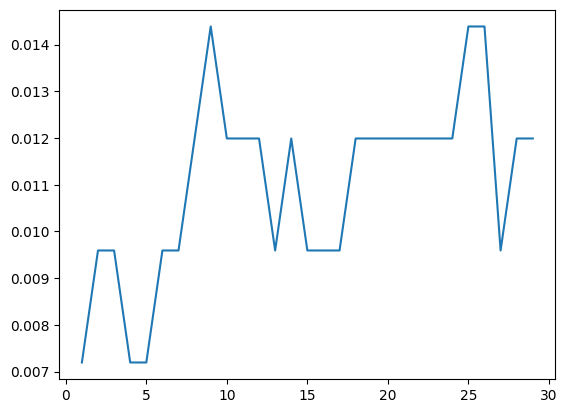

In [62]:
# Plot the error rate (Performance_Metric) against the number of neighbors (k)
# This helps in visualizing the optimal k value where the error is minimal
plt.plot(range(1,30), Performance_Metric)

###Logistic Regression and Decision Tree

In [63]:
## Logistic Regression Model
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model with a specified random state for reproducibility
lr = LogisticRegression(random_state=90, solver='lbfgs')
# Train the Logistic Regression model using the scaled training data
lr.fit(scaled_X_train, y_train)
# Make predictions on the scaled test data
y_pred_lr = lr.predict(scaled_X_test)

# Calculate and print the accuracy score for Logistic Regression
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr)}")

Logistic Regression Accuracy: 1.0


In [64]:
## Decision Tree Classifier Model
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree Classifier with a specified random state for reproducibility
dtr=DecisionTreeClassifier(random_state=78)
# Train the Decision Tree model using the scaled training data
dtr.fit(scaled_X_train, y_train)
# Make predictions on the scaled test data
y_pred_dtr = dtr.predict(scaled_X_test)

# Calculate and print the accuracy score for Decision Tree
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dtr)}")

Decision Tree Accuracy: 1.0


In [65]:
# Print the accuracy scores for all evaluated models for comparison
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr)}") # Changed y_pred_log_reg to y_pred_lr
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dtr)}") # Changed y_pred_dt to y_pred_dtr

KNN Accuracy: 0.9928057553956835
Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0


##Interpretation:

The objective of this analysis is to predict passenger survival on the Titanic using machine learning techniques. The dataset includes demographic and travel-related variables such as age, gender, passenger class, and fare, which are used to build classification models.


####  Data Preprocessing and Preparation

#### Handling Missing Values

- The "Age" variable had approximately 20% missing values and was imputed using the median, which is robust to outliers.
- The "Embarked" variable had very few missing values, so the corresponding rows were removed.
* The "Cabin" variable had more than 75% missing values and was therefore dropped due to insufficient information.

These steps ensured that the dataset contained no missing values and improved overall data quality.


#### Feature Selection

The following columns were removed:

* PassengerId: serves only as an identifier and has no predictive value
* Name and Ticket: does not contribute meaningfully to prediction

This reduced noise and improved analysis efficiency.



#### Encoding Categorical Variables

Categorical features such as Sex, Embarked, and Pclass were converted into numerical form using one-hot encoding (dummy variables).

This step is necessary because machine learning algorithms require numerical input.



#### Data Splitting

The dataset was divided into training and testing sets to evaluate model performance on unseen data.


#### Feature Scaling

Standardization was applied using StandardScaler to normalize numerical features.

* This is important for distance-based and optimization-based models such as KNN and Logistic Regression.
* Although not required for Decision Trees, applying scaling does not negatively affect performance.


####  Model Implementation and Results

#### K-Nearest Neighbors (KNN)

* Accuracy:  0.993

KNN is a distance-based algorithm that classifies data points based on the majority class among their nearest neighbors. The high accuracy indicates that similar data points tend to share the same class. However, KNN is sensitive to the choice of the parameter K and to noise in the data.


#### Logistic Regression

* Accuracy: 1.0

Logistic Regression is a linear classification model that estimates the probability of survival. The perfect accuracy suggests that there is clear cut differentation in the dataset. Important variables such as gender, passenger class, and fare likely play a strong role in prediction.

This model is generally stable, interpretable, and less prone to overfitting compared to more complex models.


#### Decision Tree Classifier

* Accuracy: 1.0

The Decision Tree model builds a set of rules by splitting the dataset based on feature values. The perfect accuracy indicates that the model was able to create splits that completely separate the classes.

However, Decision Trees are highly flexible and prone to overfitting, especially when no constraints (such as maximum depth) are applied. This means the model may have memorized patterns specific to the dataset rather than learning generalizable relationships.

#### Comparative Analysis of Models

* KNN performs well but is sensitive to parameters and scaling.
* Logistic Regression provides a good balance between performance and interpretability.
* Decision Tree offers high flexibility but has a higher risk of overfitting.



#### Key Insights from the Data

* "Gender" is a major factor influencing survival, with females having higher survival rates.
* "Passenger Class" is significant, as passengers in higher classes had better chances of survival.
* Fare" is positively related with survival, indicating that wealthier passengers were more likely to survive.



#### Observation

Both Logistic Regression and Decision Tree achieved perfect accuracy, which is uncommon in real-world datasets. This suggests that:

* The dataset used for testing could be very similar to the training data, or
* The preprocessing steps made the classification problem highly separable, or
* The Decision Tree model may have overfitted the data

Therefore, while the results indicate strong model performance, they  may not generalize to new data.
